In [1]:
#Read the datasets
import pandas as pd

df1 = pd.read_csv("../../Data/atlas_vivli_2004_2024.csv")

df2 = pd.read_excel(
    "../../Data/Omadacycline_2015 to 2025_Surveillance_data.xlsx",
    engine="openpyxl"
)

print("Dataset 2:", df2.shape)



/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_77097/3624946799.py:4: DtypeWarning: Columns (0: State, 1: Ampicillin sulbactam, 2: Ampicillin sulbactam_I, 3: Azithromycin, 4: Aztreonam, 5: Aztreonam avibactam, 6: Aztreonam_I, 7: Cefiderocol, 8: Cefiderocol_I, 9: Cefixime, 10: Cefixime_I, 11: Cefoperazone sulbactam, 12: Cefoxitin, 13: Cefoxitin_I, 14: Cefpodoxime, 15: Cefpodoxime_I, 16: Ceftaroline, 17: Ceftaroline_I, 18: Ceftazidime avibactam, 19: Ceftazidime avibactam_I, 20: Ceftibuten, 21: Ceftibuten_I, 22: Ceftolozane tazobactam, 23: Ceftolozane tazobactam_I, 24: Ciprofloxacin, 25: Ciprofloxacin_I, 26: Clarithromycin, 27: Clarithromycin_I, 28: Colistin, 29: Colistin_I, 30: Daptomycin, 31: Daptomycin_I, 32: Doripenem, 33: Doripenem_I, 34: Ertapenem, 35: Ertapenem_I, 36: Gatifloxacin, 37: Gentamicin, 38: Gentamicin_I, 39: Imipenem, 40: Imipenem_I, 41: Meropenem vaborbactam, 42: Meropenem vaborbactam_I, 43: Metronidazole, 44: Metronidazole_I, 45: Minocycline, 46: Minocyclin

Dataset 2: (96302, 46)


In [2]:
df2.head()
print(df2.shape)


(96302, 46)


In [3]:
print(df2.columns[:10])

Index(['Collection \nNumber', 'Study Year', 'Organism', 'Omadacycline',
       'Doxycycline', 'Minocycline', 'Tetracycline', 'Tigecycline',
       'Oxacillin', 'Ceftaroline'],
      dtype='str')


In [4]:
#Create clean dataframe for analysis
df_clean = df2.copy()

In [5]:
#Define function to clean MIC values (handle >, <=, and convert to float)
#>8 → 8
#<=0.25 → 0.25
#numeric stays same

def clean_mic(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()

    if value.startswith(">"):
        return float(value.replace(">", ""))
    
    if value.startswith("<="):
        return float(value.replace("<=", ""))
    
    try:
        return float(value)
    except:
        return np.nan

In [6]:
#Define antibiotic columns based on your dataset structure
antibiotic_cols = df_clean.columns[3:]
print(df_clean.columns[3:].tolist())
# Check the number of columns 
num_antibiotic_cols = len(antibiotic_cols)

print(f"Number of antibiotic columns: {num_antibiotic_cols}")

['Omadacycline', 'Doxycycline', 'Minocycline', 'Tetracycline', 'Tigecycline', 'Oxacillin', 'Ceftaroline', 'Ceftriaxone', 'Amoxicillin-\nclavulanic acid', 'Piperacillin-\ntazobactam', 'Levofloxacin', 'Erythromycin', 'Clindamycin', 'Linezolid', 'Daptomycin', 'Vancomycin', 'Teicoplanin', 'Gentamicin', 'Amikacin', 'Ampicillin', 'Azithromycin', 'Aztreonam', 'Cefepime', 'Ceftazidime', 'Colistin', 'Imipenem', 'Moxifloxacin', 'Penicillin', 'Trimethoprim-\nsulfamethoxazole', 'Continent', 'Country', 'US Census Division', 'Nosocomial', 'Age', 'Gender', 'Medical Service', 'Infection Source', 'Infection Type', 'Source of Bloodstream infection', 'Specimen Type', 'Ventilator-Associated Pneumonia', 'Intensive\nCare Unit\n(ICU)', 'Cystic Fibrosis (CF)\nPatient']
Number of antibiotic columns: 43


In [7]:
import numpy as np

#Apply cleaning function to antibiotic columns
for col in antibiotic_cols:
    df_clean[col] = df_clean[col].apply(clean_mic)
#Check cleaned data
df_clean[antibiotic_cols].head()

,Omadacycline,Doxycycline,Minocycline,Tetracycline,Tigecycline,Oxacillin,Ceftaroline,Ceftriaxone,Amoxicillin-\nclavulanic acid,Piperacillin-\ntazobactam,...,Age,Gender,Medical Service,Infection Source,Infection Type,Source of Bloodstream infection,Specimen Type,Ventilator-Associated Pneumonia,Intensive\nCare Unit\n(ICU),Cystic Fibrosis (CF)\nPatient
0,0.03,NaN,NaN,1.0,0.03,NaN,NaN,NaN,NaN,4.0,...,79.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.50,4.00,NaN,8.0,0.25,2.0,NaN,8.0,NaN,16.0,...,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.25,NaN,NaN,8.0,0.12,NaN,NaN,NaN,NaN,4.0,...,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.12,0.06,NaN,0.5,0.06,2.0,NaN,8.0,NaN,16.0,...,77.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.06,0.06,NaN,0.5,0.06,2.0,NaN,8.0,NaN,16.0,...,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
#Convert MIC(Minimum Inhibitory Concentration) into S/I/R categories based on CLSI breakpoints (example for E. coli and Ciprofloxacin)
def mic_to_sir(x):
    if pd.isna(x):
        return np.nan
    elif x <= 1:
        return "S"
    elif x <= 4:
        return "I"
    else:
        return "R"

In [9]:
#How resistant/susceptible are the isolates in the dataset for each antibiotic?
sir_df[antibiotic_cols].apply(pd.Series.value_counts).T.fillna(0)

NameError: name 'sir_df' is not defined

In [ ]:
metadata_cols = [
    "Collection \nNumber",
    "Study Year",
    "Organism",
    "Continent",
    "Country",
    "US Census Division",
    "Nosocomial",
    "Age",
    "Gender",
    "Medical Service",
    "Infection Source",
    "Infection Type",
    "Source of Bloodstream infection",
    "Specimen Type",
    "Ventilator-Associated Pneumonia",
    "Intensive\nCare Unit\n(ICU)",
    "Cystic Fibrosis (CF)\nPatient"
]
antibiotic_cols = [
    col for col in df_clean.columns
    if col not in metadata_cols
]
print(len(antibiotic_cols))
print(antibiotic_cols)

29
['Omadacycline', 'Doxycycline', 'Minocycline', 'Tetracycline', 'Tigecycline', 'Oxacillin', 'Ceftaroline', 'Ceftriaxone', 'Amoxicillin-\nclavulanic acid', 'Piperacillin-\ntazobactam', 'Levofloxacin', 'Erythromycin', 'Clindamycin', 'Linezolid', 'Daptomycin', 'Vancomycin', 'Teicoplanin', 'Gentamicin', 'Amikacin', 'Ampicillin', 'Azithromycin', 'Aztreonam', 'Cefepime', 'Ceftazidime', 'Colistin', 'Imipenem', 'Moxifloxacin', 'Penicillin', 'Trimethoprim-\nsulfamethoxazole']


In [ ]:
antibiotic_summary = sir_df.drop(columns=metadata_cols, errors="ignore")

In [ ]:
#Calculate the resistance rate (R divided by the sum of I + R + S)
resistance_rate = antibiotic_summary.apply(
    lambda col: (col == "R").sum() / (col.isin(["S", "I", "R"]).sum() or 1)
)

#  Sort from highest resistance to lowest and get the top 10
most_resistant_drugs = resistance_rate.sort_values(ascending=False).head(10)

print("--- Top 10 Most Resistant Antibiotics (by % R) ---")
# Multiply by 100 to show clean percentages
print((most_resistant_drugs * 100).round(2))

--- Top 10 Most Resistant Antibiotics (by % R) ---
Erythromycin                 38.30
Piperacillin-\ntazobactam    29.09
Ampicillin                   26.77
Doxycycline                  25.30
Tetracycline                 24.96
Cefepime                     20.74
Ceftazidime                  20.38
Minocycline                  19.92
Aztreonam                    17.35
Ceftriaxone                  15.26
dtype: float64


In [ ]:
# Most effectiveness antibiotics(S divided by the sum of I + R + S)
effectiveness_rate = antibiotic_summary.apply(
    lambda col: (col == "S").sum() / (col.isin(["S", "I", "R"]).sum() or 1)
)

# Sort from highest effectiveness to lowest and get the top 10
most_effective_drugs = effectiveness_rate.sort_values(ascending=False).head(10)

print("--- Top 10 Most Effective Antibiotics (by % S) ---")
# Multiply by 100 to show clean percentages
print((most_effective_drugs * 100).round(2))

--- Top 10 Most Effective Antibiotics (by % S) ---
Moxifloxacin                     99.46
Ceftaroline                      98.37
Daptomycin                       97.22
Colistin                         96.68
Vancomycin                       92.87
Tigecycline                      87.57
Amoxicillin-\nclavulanic acid    86.53
Imipenem                         86.37
Clindamycin                      84.17
Penicillin                       83.05
dtype: float64


In [ ]:
#Organism level antibiotic behaviour
organism_drug_resistance = df2.groupby("Organism")[df2.select_dtypes("number").columns].mean()
organism_drug_resistance.head()

,Collection \nNumber,Study Year,Age
Organism,,,
Acinetobacter baumannii,1.222803e+06,2021.000000,66.000000
Acinetobacter baumannii-calcoaceticus species complex,1.176566e+06,2020.124760,54.494054
Acinetobacter beijerinckii,1.177988e+06,2020.333333,67.000000
Acinetobacter bereziniae,1.196943e+06,2020.965517,39.592593
Acinetobacter courvalinii,1.180964e+06,2020.545455,34.363636


In [ ]:
#Hardest organism to kill
numeric_cols = df2.select_dtypes(include="number").columns

organism_hardness = df2.groupby("Organism")[numeric_cols].mean().mean(axis=1)

organism_hardness.sort_values(ascending=False).head(10)

Organism
Enterococcus gilvus             644339.500000
Unspeciated Staphylococcus      520542.500000
Unspeciated Enterobacter        431260.666667
Acinetobacter nosocomialis      431058.666667
Pantoea piersonii               423619.333333
Acinetobacter proteolyticus     422166.444444
Staphylococcus saprophyticus    413785.494407
Acinetobacter vivianii          410996.822222
Acinetobacter variabilis        410374.333333
Pantoea anthophila              409265.666667
dtype: float64

In [ ]:
#Antibiotic failure  by organism
drug_failure = df2.groupby("Organism")[numeric_cols].mean()
drug_failure.head()

,Collection \nNumber,Study Year,Age
Organism,,,
Acinetobacter baumannii,1.222803e+06,2021.000000,66.000000
Acinetobacter baumannii-calcoaceticus species complex,1.176566e+06,2020.124760,54.494054
Acinetobacter beijerinckii,1.177988e+06,2020.333333,67.000000
Acinetobacter bereziniae,1.196943e+06,2020.965517,39.592593
Acinetobacter courvalinii,1.180964e+06,2020.545455,34.363636


In [ ]:

# failing drugs for organism
top_failures = drug_failure.apply(lambda x: x.sort_values(ascending=False).head(3), axis=1)
print(top_failures.head())

                                                    Collection \nNumber  \
Organism                                                                  
Acinetobacter baumannii                                    1.222803e+06   
Acinetobacter baumannii-calcoaceticus species c...         1.176566e+06   
Acinetobacter beijerinckii                                 1.177988e+06   
Acinetobacter bereziniae                                   1.196943e+06   
Acinetobacter courvalinii                                  1.180964e+06   

                                                     Study Year        Age  
Organism                                                                    
Acinetobacter baumannii                             2021.000000  66.000000  
Acinetobacter baumannii-calcoaceticus species c...  2020.124760  54.494054  
Acinetobacter beijerinckii                          2020.333333  67.000000  
Acinetobacter bereziniae                            2020.965517  39.592593  
Acinetobacte

In [ ]:
# Calculate the mean MIC value for each antibiotic
overall_drug_failure = (
    df_clean[antibiotic_cols]
    .mean()
    .sort_values(ascending=False)
)

# Display the top 10 antibiotics with the highest average MIC
print("Top 10 antibiotics with the highest average MIC:")
print(overall_drug_failure.head(10))

Top 10 antibiotics with the highest average MIC:
Piperacillin-\ntazobactam    16.971421
Gentamicin                    8.366606
Cefepime                      8.019054
Ceftazidime                   5.793269
Tetracycline                  4.308879
Erythromycin                  4.038031
Amikacin                      3.962530
Minocycline                   3.900023
Ampicillin                    3.882288
Omadacycline                  3.554535
dtype: float64


In [ ]:
# Mean failure rate per organism across all drugs
overall_organism_failure = drug_failure.mean(axis=1).sort_values(ascending=False)
print(overall_organism_failure.head(10))

Organism
Enterococcus gilvus             644339.500000
Unspeciated Staphylococcus      520542.500000
Unspeciated Enterobacter        431260.666667
Acinetobacter nosocomialis      431058.666667
Pantoea piersonii               423619.333333
Acinetobacter proteolyticus     422166.444444
Staphylococcus saprophyticus    413785.494407
Acinetobacter vivianii          410996.822222
Acinetobacter variabilis        410374.333333
Pantoea anthophila              409265.666667
dtype: float64


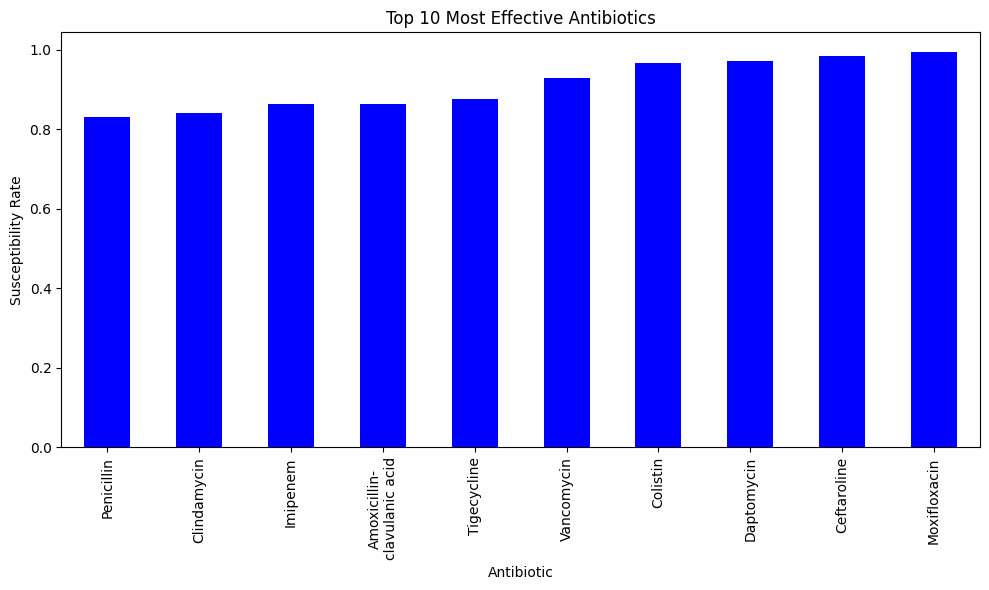

In [ ]:
#Most Effective Antibiotics
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

most_effective_drugs.sort_values().plot(
    kind="bar",
    color="blue"
)

plt.title("Top 10 Most Effective Antibiotics")
plt.ylabel("Susceptibility Rate")
plt.xlabel("Antibiotic")
plt.tight_layout()
plt.savefig(
    "../../outputs/figures/top_effective_antibiotics.png"
)
plt.show()


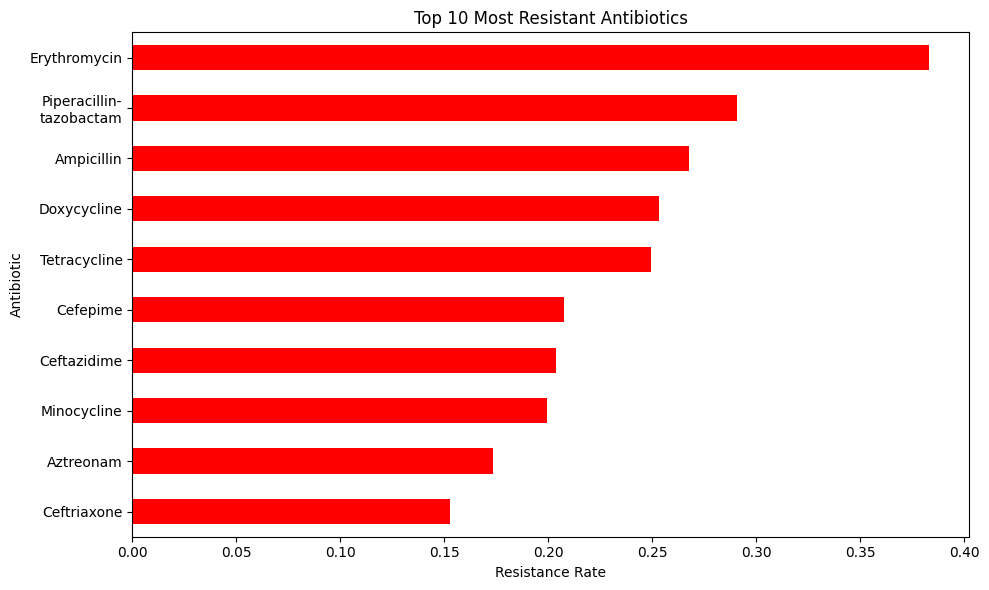

In [ ]:
#Most Resistant Antibiotics
plt.figure(figsize=(10,6))

most_resistant_drugs.sort_values().plot(
    kind="barh",
    color="red"
)

plt.title("Top 10 Most Resistant Antibiotics")
plt.xlabel("Resistance Rate")
plt.ylabel("Antibiotic")
plt.tight_layout()
plt.savefig(
    "../../outputs/figures/most_resistant_antibiotics.png"
)
plt.show()

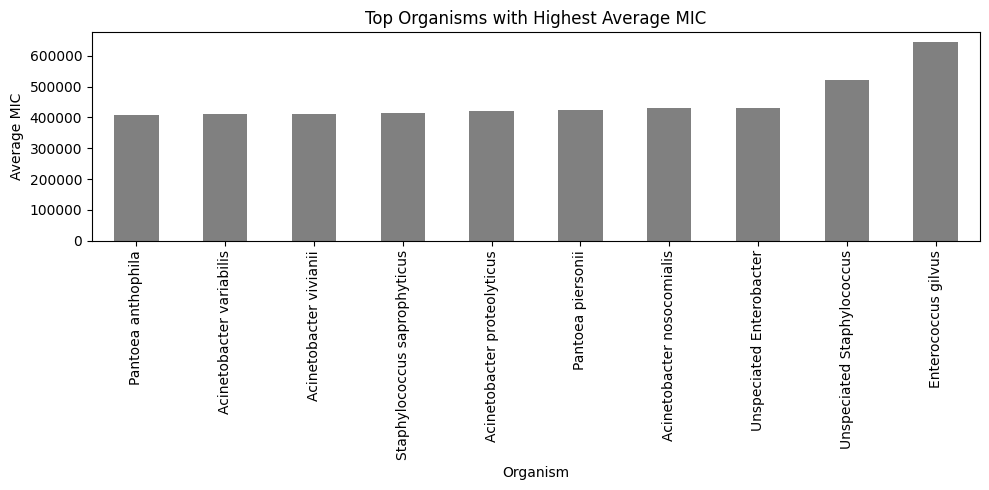

In [ ]:
#Hardest organism to kill
overall_organism_failure.head(10).sort_values().plot(
    kind="bar",
    figsize=(10,5),
    color="grey"
)

plt.title("Top Organisms with Highest Average MIC")
plt.ylabel("Average MIC")
plt.xlabel("Organism")
plt.tight_layout()
plt.savefig(
    "../../outputs/figures/hardest_organisms_to_kill.png"
)
plt.show()

In [ ]:
import seaborn as sns
#Organism *Antibiotic heatmap
heatmap_data = (
    df_clean
    .groupby("Organism")[antibiotic_cols]
    .mean()
)

heatmap_data.head()

,Omadacycline,Doxycycline,Minocycline,Tetracycline,Tigecycline,Oxacillin,Ceftaroline,Ceftriaxone,Amoxicillin-\nclavulanic acid,Piperacillin-\ntazobactam,...,Ampicillin,Azithromycin,Aztreonam,Cefepime,Ceftazidime,Colistin,Imipenem,Moxifloxacin,Penicillin,Trimethoprim-\nsulfamethoxazole
Organism,,,,,,,,,,,,,,,,,,,,,
Acinetobacter baumannii,0.500000,0.250000,0.120000,2.000000,0.500000,NaN,NaN,NaN,NaN,0.060000,...,NaN,NaN,NaN,4.000000,NaN,NaN,0.120000,NaN,NaN,0.250000
Acinetobacter baumannii-calcoaceticus species complex,2.473287,2.746473,2.266694,8.590494,1.553709,NaN,NaN,NaN,NaN,57.267862,...,NaN,NaN,NaN,22.183926,NaN,NaN,3.866132,NaN,NaN,2.738282
Acinetobacter beijerinckii,0.333333,0.120000,0.060000,1.333333,0.250000,NaN,NaN,NaN,NaN,0.060000,...,NaN,NaN,NaN,1.333333,NaN,NaN,0.120000,NaN,NaN,0.120000
Acinetobacter bereziniae,0.216897,0.283448,0.096818,3.310345,0.313793,NaN,NaN,NaN,NaN,2.700000,...,NaN,NaN,NaN,1.913793,NaN,NaN,0.676552,NaN,NaN,0.246897
Acinetobacter courvalinii,0.647273,0.260000,0.077143,2.454545,0.727273,NaN,NaN,NaN,NaN,6.492727,...,NaN,NaN,NaN,1.636364,NaN,NaN,0.409091,NaN,NaN,0.328182


In [ ]:
## subset only antibiotic columns for heatmap
antibiotic_cols = [
    c for c in df_clean.columns
    if c not in metadata_cols
]

heatmap_data = (
    df_clean
    .groupby("Organism")[antibiotic_cols]
    .mean()
)

In [ ]:
top_organisms = (
    df_clean["Organism"]
    .value_counts()
    .head(20)
    .index
)

heatmap_data = heatmap_data.loc[top_organisms]
heatmap_data.head()

,Omadacycline,Doxycycline,Minocycline,Tetracycline,Tigecycline,Oxacillin,Ceftaroline,Ceftriaxone,Amoxicillin-\nclavulanic acid,Piperacillin-\ntazobactam,...,Ampicillin,Azithromycin,Aztreonam,Cefepime,Ceftazidime,Colistin,Imipenem,Moxifloxacin,Penicillin,Trimethoprim-\nsulfamethoxazole
Organism,,,,,,,,,,,,,,,,,,,,,
Staphylococcus aureus,0.139913,0.326012,0.270933,0.984318,0.092397,1.046181,0.451969,5.559474,NaN,7.085894,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.674508
Escherichia coli,0.918381,3.106947,2.671764,6.189130,0.186035,NaN,NaN,1.515283,NaN,6.868731,...,NaN,NaN,2.589361,7.343510,3.664626,NaN,0.149597,NaN,NaN,2.716915
Pseudomonas aeruginosa,26.658526,7.637338,15.201141,NaN,6.695688,NaN,NaN,NaN,NaN,22.784035,...,NaN,NaN,NaN,6.803502,7.368680,0.77635,2.460687,NaN,NaN,NaN
Klebsiella pneumoniae,2.796785,3.221636,5.164611,5.359946,0.610437,NaN,NaN,2.055392,NaN,18.721979,...,NaN,NaN,3.904988,12.849234,6.991101,NaN,0.612372,NaN,NaN,2.252275
Streptococcus pneumoniae,0.062043,0.264440,0.266007,1.200474,0.047159,NaN,0.034345,0.223045,0.462778,NaN,...,NaN,2.841581,NaN,NaN,NaN,NaN,NaN,NaN,0.425457,0.997617


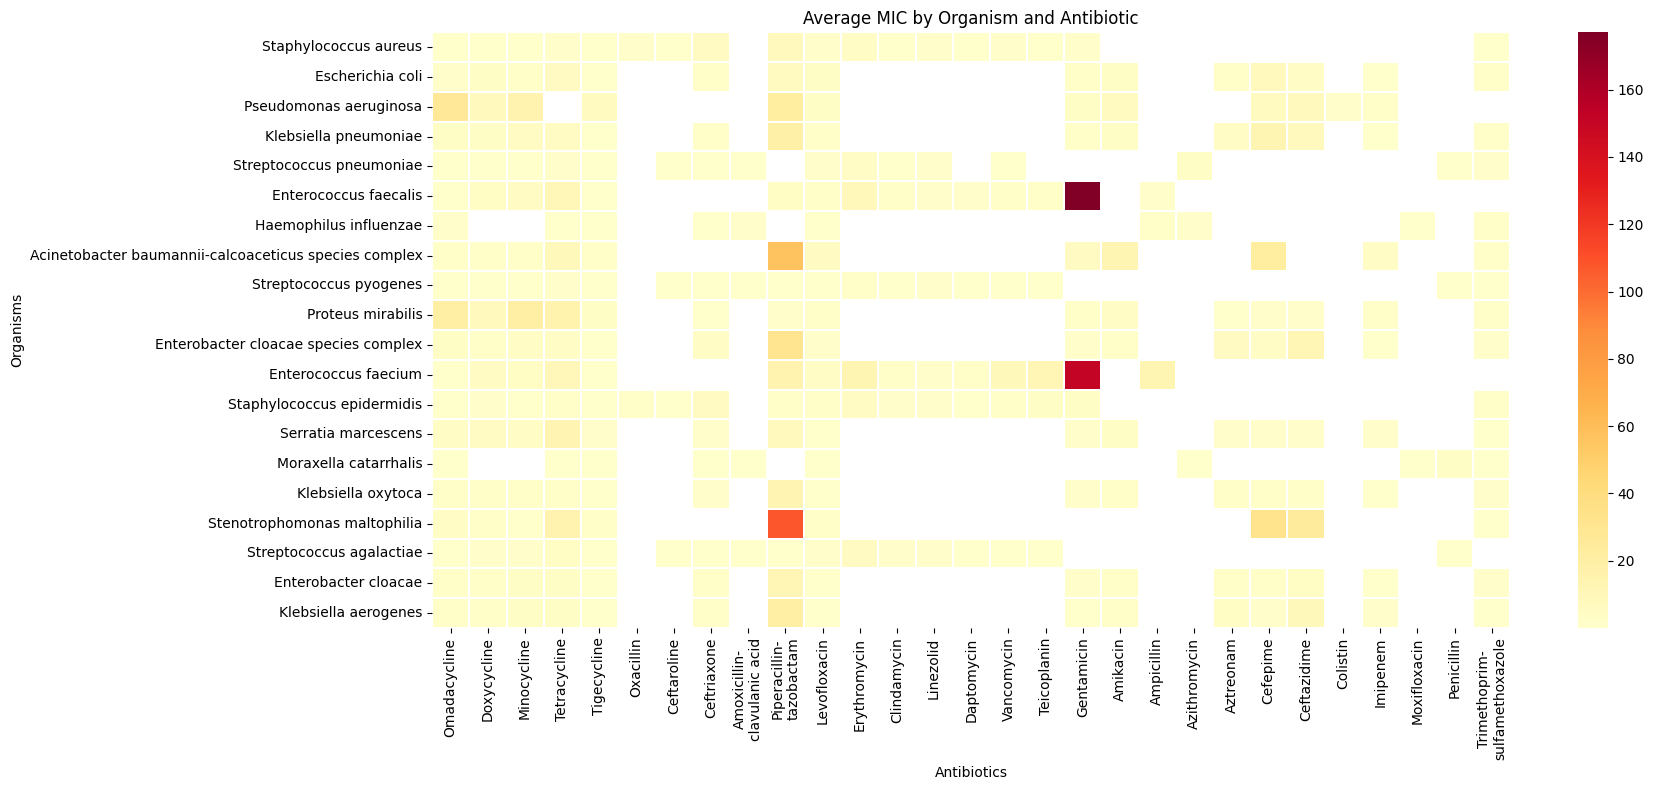

In [ ]:
#Heatmap of average MIC values by organism and antibiotic
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.3
)

plt.title("Average MIC by Organism and Antibiotic")
plt.xlabel("Antibiotics")
plt.ylabel("Organisms")

plt.tight_layout()
plt.savefig(
    "../../outputs/figures/heatmap_average_mic.png"
)
plt.show()

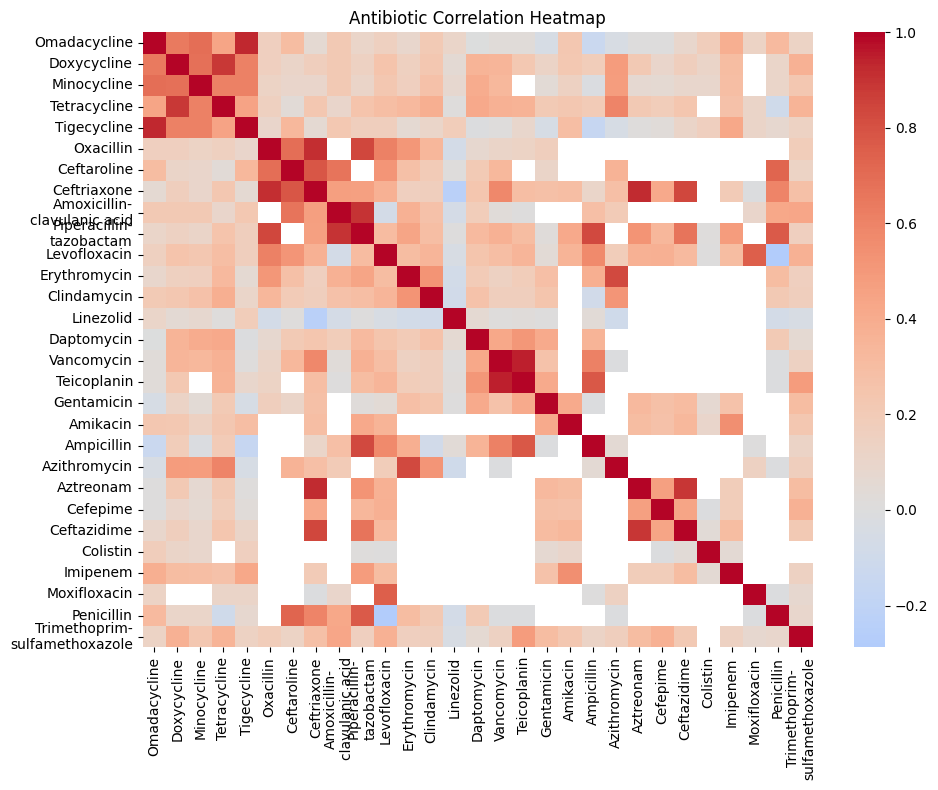

In [ ]:
#Correlation heatmap of antibiotic MIC values across the dataset
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

corr = df_clean[antibiotic_cols].corr()

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Antibiotic Correlation Heatmap")
plt.tight_layout()
plt.savefig(
    "../../outputs/figures/antibiotic_correlation_heatmap.png"
)
plt.show()

In [ ]:
most_effective_drugs.to_csv(
    "../../outputs/tables/most_effective_antibiotics.csv"
)
most_resistant_drugs.to_csv(
    "../../outputs/tables/most_resistant_antibiotics.csv"
)

overall_organism_failure.to_csv(
    "../../outputs/tables/organism_risk.csv"
)

heatmap_data.to_csv(
    "../../outputs/tables/organism_antibiotic_matrix.csv"
)